# Week 08 Lab — Deep Learning Basics: MLP and CNN (Student)

**Instructions**: fill in every `___` blank and implement every `# TODO` comment.
Do *not* look at the solutions notebook until you have tried each step yourself!

Run cells in order — each step depends on variables set in the previous one.

---
# Part 1 — Simple Multi-Layer Perceptron (MLP) on MNIST

In this part you will build, train, and evaluate a fully-connected neural
network to classify handwritten digits from the MNIST dataset.

**Learning goals**
- Understand how to prepare image data for a dense neural network
- Build a Sequential Keras model with `Dense` layers
- Train and evaluate a model on a real dataset


## Step 1 — Imports

Import all libraries needed for the MLP experiment.


In [8]:
from __future__ import print_function

import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import RMSprop
import numpy as np
from tensorflow.python.keras.utils import np_utils
import matplotlib.pyplot as plt

## Step 2 — Set Parameters and Load MNIST Data

MNIST contains 70 000 greyscale images of handwritten digits (28×28 pixels).


In [2]:
# TODO 2a: Set batch_size = 20000
# TODO 2b: Set num_classes = 10  (digits 0–9)
# TODO 2c: Set epochs = 5

batch_size  = 20000
num_classes = 10
epochs      = 5

# TODO 2d: Load the MNIST dataset into (x_train, y_train), (x_test, y_test)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# TODO 2e: Print the shape of x_train
print("x_train shape:", x_train.shape)

# TODO 2f: How many training samples belong to digit '8'?
print("Number of 8s in training set:", np.sum(y_train == 8))


x_train shape: (60000, 28, 28)
Number of 8s in training set: 5851


## Step 3 — Visualise a Sample

Before preprocessing, inspect a raw image and its label.


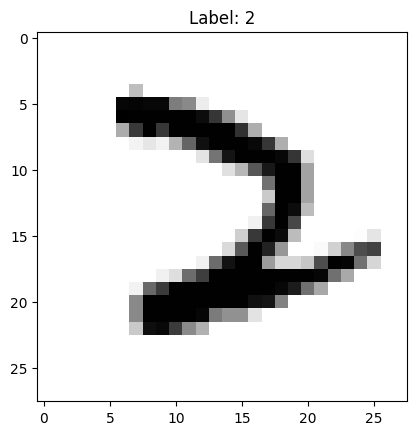

In [3]:
# TODO 3a: Display the image at index 3890 using plt.imshow
#          Use cmap=plt.cm.binary so the digit appears dark on white
# TODO 3b: Print the label (y_train value) at that index

plt.imshow(x_train[3890], cmap=plt.cm.binary)
plt.title("Label: " + str(y_train[3890]))
plt.show()


## Step 4 — Preprocess the Data

Dense layers expect a 1-D feature vector, not a 2-D image, so we must
**flatten** each 28×28 image into a vector of length 784.
We also **normalise** pixel values from [0, 255] to [0, 1].


In [4]:
# TODO 4a: Reshape x_train from (60000, 28, 28) → (60000, 784)
x_train = x_train.reshape(60000, 784)

# TODO 4b: Reshape x_test  from (10000, 28, 28) → (10000, 784)
x_test  = x_test.reshape(10000, 784)

# TODO 4c: Cast both arrays to float32
x_train = x_train.astype('float32')
x_test  = x_test.astype('float32')

# TODO 4d: Normalise to [0, 1]
x_train /= 255
x_test  /= 255

print(x_train.shape[0], "train samples")
print(x_test.shape[0],  "test samples")


60000 train samples
10000 test samples


## Step 5 — One-Hot Encode the Labels

The output layer will have 10 neurons (one per class).
We convert integer labels (e.g. `5`) into binary vectors
(e.g. `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`).


In [5]:
# TODO 5a: Print y_train[0:5] to see the integer labels before encoding
print("Before encoding:", y_train[:5])

# TODO 5b: Convert y_train to one-hot using np_utils.to_categorical
y_train = np_utils.to_categorical(y_train, num_classes)

# TODO 5c: Do the same for y_test
y_test  = np_utils.to_categorical(y_test, num_classes)

# TODO 5d: Print y_train.shape – should now be (60000, 10)
print("After encoding, y_train shape:", y_train.shape)


Before encoding: [5 0 4 1 9]
After encoding, y_train shape: (60000, 10)


## Step 6 — Build the MLP Model

We use Keras' `Sequential` API to stack layers.
Our simple MLP has:
- **One hidden layer**: 512 neurons, ReLU activation
- **One output layer**: 10 neurons (one per class), Softmax activation

> **Tip**: `model.summary()` prints a table showing every layer,
> its output shape, and the number of trainable parameters.


In [6]:
model = Sequential()

# TODO 6a: Add a Dense hidden layer with 512 neurons, relu activation
#          and input_shape=(784,)
model.add(Dense(512, activation='relu', input_shape=(784,)))

# TODO 6b: Add the output Dense layer (num_classes neurons, softmax)
model.add(Dense(num_classes, activation='softmax'))

# TODO 6c: Print the model summary
model.summary()


c:\Users\Henry\Desktop\MUSA6500_Desktop\musa-6500-spring2026-repo\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Visualise the Model Architecture

`plot_model` draws a diagram of the layer graph.


In [11]:
from keras.utils import plot_model

# TODO 7: Call plot_model with show_shapes=True and show_layer_names=True
plot_model(model, show_shapes=True, show_layer_names=True)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## Step 8 — Compile the Model

Before training we must choose:
- **Loss function** – `categorical_crossentropy` for multi-class classification
- **Optimizer** – `RMSprop` adapts the learning rate during training
- **Metric** – `accuracy` is easy to interpret


In [12]:
# TODO 8: Compile the model
model.compile(
    loss='categorical_crossentropy',          # hint: 'categorical_crossentropy'
    optimizer=RMSprop(),     # hint: RMSprop()
    metrics=['accuracy']        # hint: ['accuracy']
)


## Step 9 — Train the Model

`model.fit` runs the training loop.
The `history` object it returns lets us plot learning curves later.


In [15]:
# TODO 9: Train the model for 10 epochs
history = model.fit(
    x_train, y_train,
    batch_size=10,
    epochs=10,           # try 10
    verbose=1,
    validation_data=(x_test, y_test)   # hint: (x_test, y_test)
)


Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9740 - loss: 0.1012 - val_accuracy: 0.9763 - val_loss: 0.0902
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9803 - loss: 0.0775 - val_accuracy: 0.9739 - val_loss: 0.1182
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9847 - loss: 0.0625 - val_accuracy: 0.9818 - val_loss: 0.0837
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9874 - loss: 0.0525 - val_accuracy: 0.9801 - val_loss: 0.0946
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9897 - loss: 0.0437 - val_accuracy: 0.9802 - val_loss: 0.0988
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9923 - loss: 0.0336 - val_accuracy: 0.9787 - val_loss: 0.1034
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.9931 - loss: 0.0298 - val_accuracy: 0.9808 - val_loss: 0.1014
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9942 - loss: 0

## Step 10 — Evaluate the Model

Run the model on the held-out test set and report the final metrics.


In [16]:
# TODO 10: Evaluate the model on the test set (verbose=0)
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])


Test loss:     0.10940111428499222
Test accuracy: 0.9822999835014343


## Step 11 — Reflection

Answer the following questions in a new markdown cell:

1. How many **trainable parameters** does the MLP have?
   Where does most of the computation happen?
2. What accuracy did you achieve after 10 epochs?
   Do you think the model is overfitting or underfitting?
3. The commented-out lines in the original notebook add a second hidden
   layer and `Dropout`. Try uncommenting them. How does accuracy change?
4. Why do we need `softmax` in the output layer but `relu` in hidden layers?


---
# Part 2 — Simple Convolutional Neural Network (CNN) on MNIST

CNNs learn **spatial features** directly from 2-D images using convolutional
filters instead of flattening the image up-front.

**Learning goals**
- Understand how CNNs differ from MLPs in terms of input shape
- Build a CNN with `Conv2D`, `MaxPooling2D`, and `Dropout` layers
- Compare CNN performance with the MLP from Part 1


## Step 1 — Imports (CNN)

In addition to the MLP imports, we need CNN-specific layers.


In [1]:
from __future__ import print_function

import tensorflow as tf
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten

# TODO 1: Also import Conv2D and MaxPooling2D from keras.layers
from keras.layers import Conv2D, MaxPooling2D

from keras import backend as K
from tensorflow.python.keras.utils import np_utils


## Step 2 — Set Parameters and Load Data

CNNs keep the spatial dimensions.
The input shape for MNIST is **(28, 28, 1)** (height × width × channels).

> **channels_first vs channels_last**: Some GPU backends expect the
> channel dimension first `(1, 28, 28)`. We use `K.image_data_format()`
> to handle both cases automatically.


In [12]:
# TODO 2a: Set batch_size = 128, num_classes = 10, epochs = 12
batch_size  = 128
num_classes = 10
epochs      = 12

# TODO 2b: Set img_rows = 28, img_cols = 28
img_rows, img_cols = 28, 28

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [13]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [14]:
# TODO 2c: Reshape the data depending on K.image_data_format()
#   If 'channels_first': shape → (n_samples, 1, img_rows, img_cols)
#   If 'channels_last':  shape → (n_samples, img_rows, img_cols, 1)
if K.image_data_format() == 'channels_first':
    x_train     = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test      = x_test.reshape(x_test.shape[0],   1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train     = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test      = x_test.reshape(x_test.shape[0],   img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

# TODO 2d: Cast to float32 and normalise to [0, 1]
x_train = x_train.astype('float32') / 255
x_test  = x_test.astype('float32') / 255

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0],  'test samples')

# TODO 2e: One-hot encode labels
y_train = np_utils.to_categorical(y_train, num_classes)
y_test  = np_utils.to_categorical(y_train, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


## Step 3 — Build the CNN Model

The architecture:

| Layer | Output shape | Notes |
|---|---|---|
| Conv2D(32, 3×3, relu) | (26, 26, 32) | Learns 32 local filters |
| Conv2D(64, 3×3, relu) | (24, 24, 64) | Deeper feature maps |
| MaxPooling2D(2×2) | (12, 12, 64) | Down-samples by 2 |
| Dropout(0.25) | (12, 12, 64) | Regularisation |
| Flatten | (9216,) | Converts 3-D → 1-D |
| Dense(128, relu) | (128,) | Fully-connected |
| Dropout(0.5) | (128,) | More regularisation |
| Dense(10, softmax) | (10,) | One probability per class |


In [15]:
model = Sequential()

# TODO 3a: First Conv2D – 32 filters, 3×3 kernel, relu, correct input_shape
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))

# TODO 3b: Second Conv2D – 64 filters, 3×3 kernel, relu
model.add(Conv2D(64, (3, 3), activation='relu'))

# TODO 3c: MaxPooling with pool_size (2, 2)
model.add(MaxPooling2D(pool_size=(2, 2)))

# TODO 3d: Dropout with rate 0.25
model.add(Dropout(0.25))

# TODO 3e: Flatten
model.add(Flatten())

# TODO 3f: Dense hidden layer – 128 neurons, relu
model.add(Dense(128, activation='relu'))

# TODO 3g: Dropout with rate 0.5
model.add(Dropout(0.5))

# TODO 3h: Output layer – num_classes neurons, softmax
model.add(Dense(num_classes, activation='softmax'))

model.summary()


c:\Users\Henry\Desktop\MUSA6500_Desktop\musa-6500-spring2026-repo\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

## Step 4 — Visualise and Compile the CNN


In [16]:
from keras.utils import plot_model

# TODO 4a: Visualise the CNN model
plot_model(model, show_shapes=True, show_layer_names=True)

# TODO 4b: Compile with categorical crossentropy loss, Adadelta optimiser,
#          and accuracy metric
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adadelta(),    # hint: tf.keras.optimizers.Adadelta()
    metrics=['accuracy']
)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## Step 5 — Train the CNN

> **Note**: Training a CNN takes longer than an MLP.
> We use only **3 epochs** here for speed — try more when you have time!


In [6]:
x_train.shape

(60000, 28, 28, 1)

In [11]:
x_test.shape

(10000, 28, 28, 1)

In [17]:
# TODO 5: Train for 3 epochs and store the history
epochs = 3

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_test, y_test)
)


Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1202 - loss: 2.2959

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 10000
'y' sizes: 60000


## Step 6 — Evaluate the CNN


In [ ]:
# TODO 6: Evaluate the CNN model on the test set
score = model.evaluate(___, ___, verbose=0)
print('Test loss:    ', ___)
print('Test accuracy:', ___)


## Step 7 — Compare MLP vs CNN

Answer these questions in a new markdown cell:

1. How many **trainable parameters** does the CNN have compared to the MLP?
   Which model is more parameter-efficient?
2. After only 3 epochs the CNN accuracy may be lower than the MLP after 10
   epochs. Why might this be, and what would happen with more epochs?
3. What is the role of `MaxPooling2D` and `Dropout` in the CNN?
4. When would you prefer a CNN over an MLP for image classification?
   When might an MLP be sufficient?
